In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('50_Startups.csv')
df

,R&D Spend,Administration,Marketing Spend,State,Profit
0,165349.20,136897.80,471784.10,New York,192261.83
1,162597.70,151377.59,443898.53,California,191792.06
2,153441.51,101145.55,407934.54,Florida,191050.39
3,144372.41,118671.85,383199.62,New York,182901.99
4,142107.34,91391.77,366168.42,Florida,166187.94
5,131876.90,99814.71,362861.36,New York,156991.12
6,134615.46,147198.87,127716.82,California,156122.51
7,130298.13,145530.06,323876.68,Florida,155752.60
8,120542.52,148718.95,311613.29,New York,152211.77
9,123334.88,108679.17,304981.62,California,149759.96


In [3]:
df.shape

(50, 5)

In [4]:
df.isnull().sum()

R&D Spend          0
Administration     0
Marketing Spend    0
State              0
Profit             0
dtype: int64

In [5]:
df.duplicated().sum()

np.int64(0)

In [6]:
df.dtypes

R&D Spend          float64
Administration     float64
Marketing Spend    float64
State                  str
Profit             float64
dtype: object

In [7]:
df.describe()

,R&D Spend,Administration,Marketing Spend,Profit
count,50.000000,50.000000,50.000000,50.000000
mean,73721.615600,121344.639600,211025.097800,112012.639200
std,45902.256482,28017.802755,122290.310726,40306.180338
min,0.000000,51283.140000,0.000000,14681.400000
25%,39936.370000,103730.875000,129300.132500,90138.902500
50%,73051.080000,122699.795000,212716.240000,107978.190000
75%,101602.800000,144842.180000,299469.085000,139765.977500
max,165349.200000,182645.560000,471784.100000,192261.830000


In [8]:
cm=df.corr(numeric_only=True)

<Axes: >

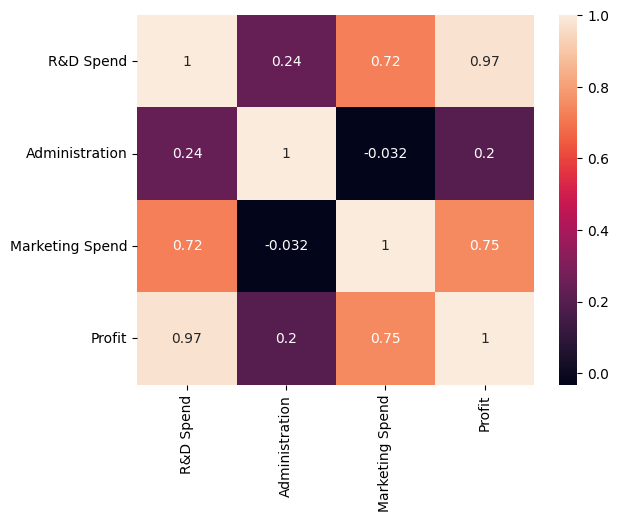

In [9]:
sns.heatmap(cm,annot=True)

<Axes: xlabel='R&D Spend', ylabel='Profit'>

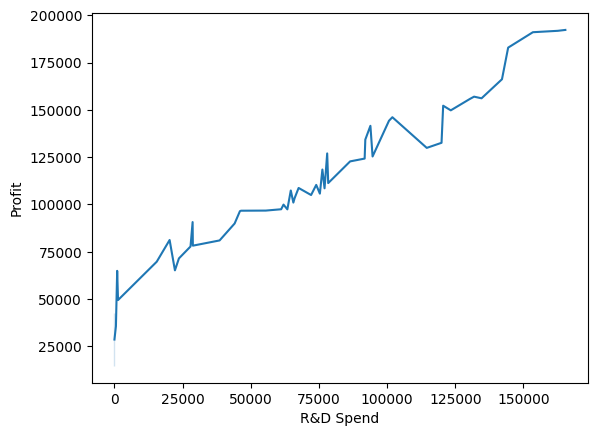

In [10]:
sns.lineplot(data=df,x='R&D Spend',y='Profit')

<Axes: xlabel='R&D Spend', ylabel='Profit'>

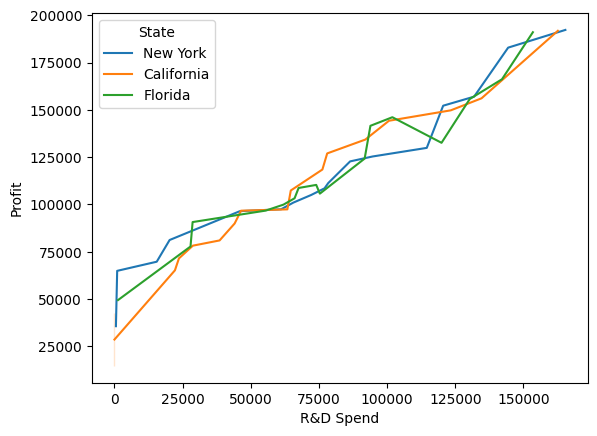

In [11]:
sns.lineplot(data=df,x='R&D Spend',y='Profit',hue='State')

<Axes: xlabel='State', ylabel='Profit'>

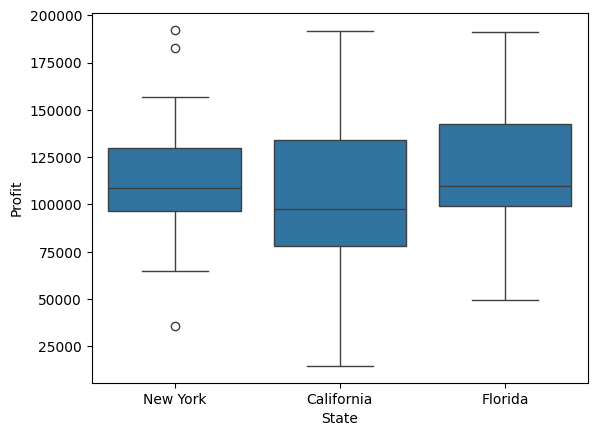

In [12]:
sns.boxplot(data=df,x='State',y='Profit')

In [13]:
X=df.drop('Profit',axis=1)
y=df['Profit']

In [14]:
from sklearn.preprocessing import OneHotEncoder
oh=OneHotEncoder(sparse_output=False)
X[oh.get_feature_names_out()]=oh.fit_transform(X[['State']])

In [15]:
X.drop(columns=oh.feature_names_in_,inplace=True)


In [16]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()
X[['R&D Spend','Administration','Marketing Spend']]=sc.fit_transform(X[['R&D Spend','Administration','Marketing Spend']])


In [17]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=12)


In [18]:
X_train.shape

(40, 6)

In [19]:
X_test.shape

(10, 6)

In [20]:
from sklearn.linear_model import LinearRegression
reg=LinearRegression()
reg.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [21]:
reg.coef_

array([36273.10038937, -1766.83377414,  3618.2472462 ,   -46.78167797,
        -723.89170024,   770.67337821])

In [22]:
reg.intercept_

np.float64(112000.45195265426)

In [23]:
reg.score(X_train,y_train)

0.9487195349700054

In [24]:
y_pred=reg.predict(X_test)

In [25]:
from sklearn.metrics import mean_absolute_error,root_mean_squared_error,r2_score

In [26]:
mean_absolute_error(y_test,y_pred)

6423.418119314332

In [27]:
root_mean_squared_error(y_test,y_pred)

8508.731962967651

In [28]:
r2_score(y_test,y_pred)

0.9473897619182121

In [29]:
import pickle

In [30]:
with open('model','wb') as f:
    pickle.dump(reg,f)


with open('encoder','wb') as f:
    pickle.dump(oh,f)


with open('scaler','wb') as f:
    pickle.dump(sc,f)


In [31]:
d1={'R&D Spend':[46014.02],'Administration':[85047.44],'Marketing Spend':[205517.64],'State':['New York']}


In [32]:
X_new=pd.DataFrame(d1)

In [33]:
X_new

,R&D Spend,Administration,Marketing Spend,State
0,46014.02,85047.44,205517.64,New York


In [34]:
X_new[oh.get_feature_names_out()]=oh.transform(X_new[['State']])
X_new.drop(columns=oh.feature_names_in_,inplace=True)

In [35]:
X_new[['R&D Spend','Administration','Marketing Spend']]=sc.transform(X_new[['R&D Spend','Administration','Marketing Spend']])

In [36]:
reg.predict(X_new)

array([92801.17932099])